In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df =pd.read_csv('data/Metro_Interstate_Traffic_Volume.csv')


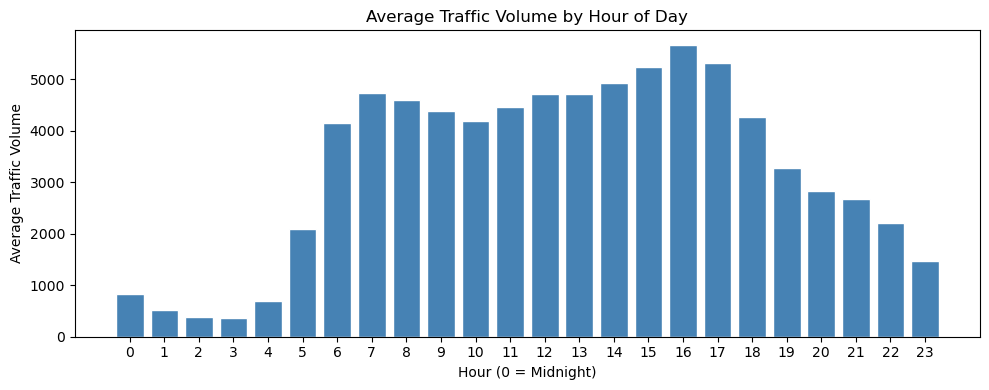

In [26]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour

hourly = df.groupby('hour')['traffic_volume'].mean()

plt.figure(figsize=(10, 4))
plt.bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
plt.title('Average Traffic Volume by Hour of Day')
plt.xlabel('Hour (0 = Midnight)')
plt.ylabel('Average Traffic Volume')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

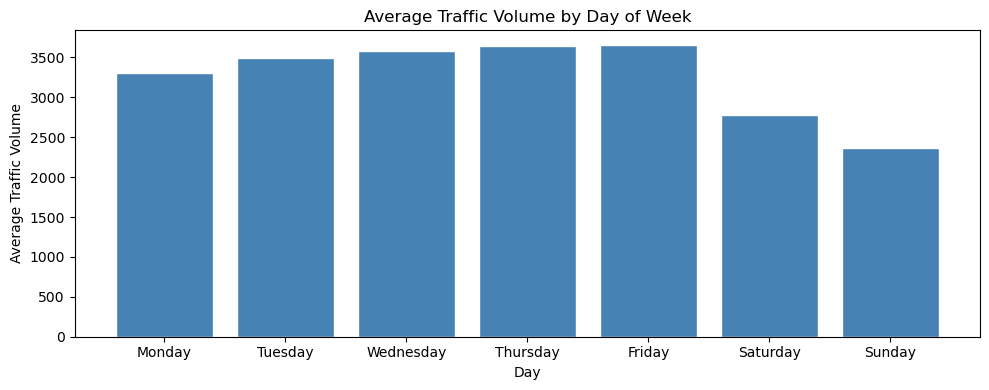

In [27]:
df['day_of_week'] = df['date_time'].dt.dayofweek

daily = df.groupby('day_of_week')['traffic_volume'].mean()

days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(10, 4))
plt.bar(days, daily.values, color='steelblue', edgecolor='white')
plt.title('Average Traffic Volume by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Traffic Volume')
plt.tight_layout()
plt.show()

In [28]:
df['hour'] = df['date_time'].dt.hour
df['month'] = df['date_time'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['is_rush_hour'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 18) else 0)
df['temp_celsius'] = df['temp'] - 273.15
df['is_holiday'] = df['holiday'].apply(lambda x: 0 if pd.isna(x) else 1)

print(df[['hour', 'month', 'is_weekend', 'is_rush_hour', 'temp_celsius', 'is_holiday']].head())

   hour  month  is_weekend  is_rush_hour  temp_celsius  is_holiday
0     9     10           0             1         15.13           0
1    10     10           0             0         16.21           0
2    11     10           0             0         16.43           0
3    12     10           0             0         16.98           0
4    13     10           0             0         17.99           0


In [29]:

features = ['hour', 'month', 'is_weekend', 'is_rush_hour', 'temp_celsius', 'is_holiday', 'clouds_all', 'rain_1h', 'snow_1h']

X = df[features]
Y = df['traffic_volume']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)



In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [31]:
model = LinearRegression()
model.fit(X_train_scaled, Y_train)

Y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2 Score: {r2:.2f}')


RMSE: 1585.44
MAE: 1369.48
R2 Score: 0.36


# Polynomial Feature

In [32]:

df['hour_squared'] = df['hour'] ** 2
features = ['hour', 'month', 'is_weekend', 'is_rush_hour', 'temp_celsius', 'is_holiday', 'clouds_all', 'rain_1h', 'snow_1h', 'hour_squared']

X = df[features]
Y = df['traffic_volume']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, Y_train)

Y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2 Score: {r2:.2f}')



RMSE: 1027.13
MAE: 795.63
R2 Score: 0.73


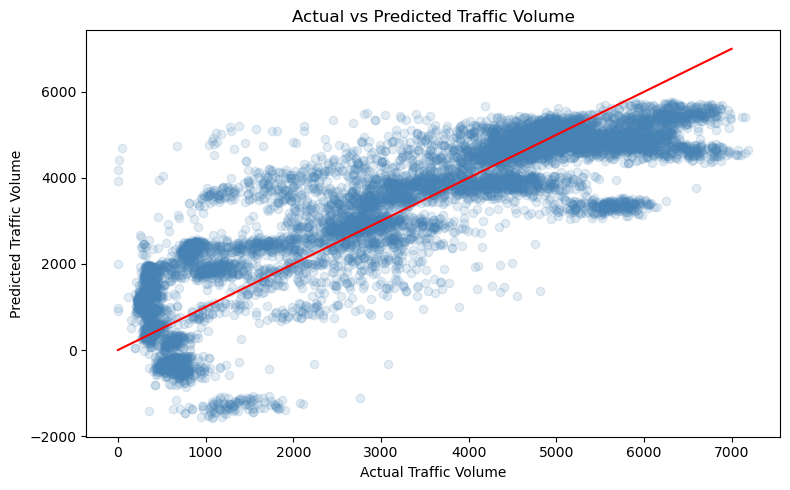

In [33]:
plt.figure(figsize=(8, 5))
plt.scatter(Y_test, Y_pred, alpha=0.15, color='steelblue')
plt.plot([0, 7000], [0, 7000], color='red', linewidth=1.5, )
plt.title('Actual vs Predicted Traffic Volume')
plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.tight_layout()
plt.show()

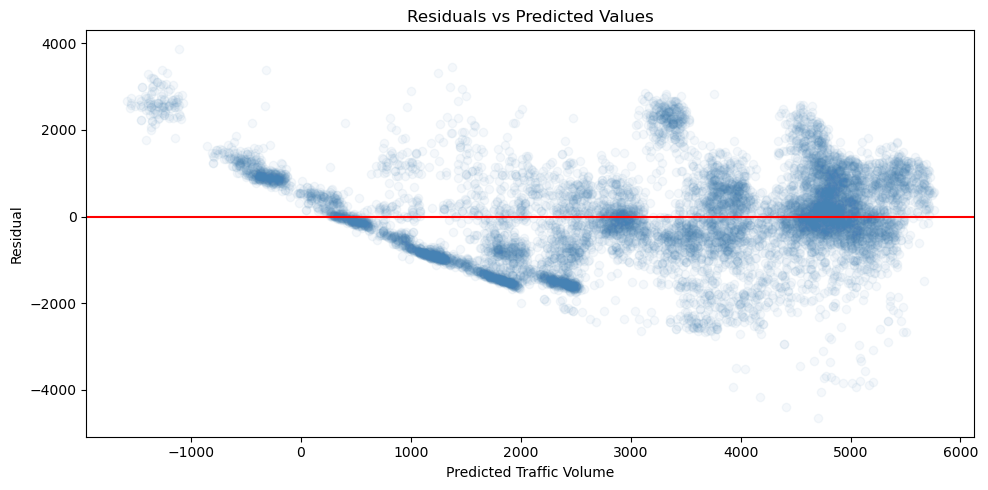

In [34]:
residuals = Y_test - Y_pred

plt.figure(figsize=(10, 5))
plt.scatter(Y_pred, residuals, alpha=0.05, color='steelblue')
plt.axhline(0, color='red', linewidth=1.5)
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Traffic Volume')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

In [35]:
print(f'Negative predictions: {(Y_pred < 0).sum()}')
print(f'Out of: {len(Y_pred)} total predictions') 

Negative predictions: 517
Out of: 9641 total predictions


In [36]:
scenario = pd.DataFrame({
    'hour': [8],
    'month': [1],
    'is_weekend': [0],
    'is_rush_hour': [1],
    'temp_celsius': [2], 
    'is_holiday': [0],
    'clouds_all': [80],
    'rain_1h': [5],
    'snow_1h': [0],
    'hour_squared': [64]
})

scenario_scaled = scaler.transform(scenario)
prediction = model.predict(scenario_scaled)

print(f'Scenario: 8am, rainy weekday, January, 2 degrees celsius')
print(f'Predicted traffic volume: {prediction[0]:.0f} vehicles/hour')

Scenario: 8am, rainy weekday, January, 2 degrees celsius
Predicted traffic volume: 4949 vehicles/hour
